# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [2]:
# TODO: завантажте meters.parquet і registry.csv свого варіанта з папки variants/<варіант>/
df_meters = pd.read_parquet("meters.parquet")
df_registry = pd.read_csv("registry.csv")

print("meters.parquet:")
print(df_meters.head())
print(df_meters.tail())
print(df_meters.shape)
print(df_meters.dtypes)

print("\nregistry.csv:")
print(df_registry.head())
print(df_registry.shape)
print(df_registry.dtypes)

meters.parquet:
   meter_id                  ts  consumption_kwh           record_ts
0  UA101476 2026-01-05 00:00:00           1827.3 2026-01-05 00:08:04
1  UA101476 2026-01-05 01:00:00           1709.5 2026-01-05 01:12:38
2  UA101476 2026-01-05 02:00:00           1799.1 2026-01-05 02:10:58
3  UA101476 2026-01-05 03:00:00           1818.5 2026-01-05 03:03:21
4  UA101476 2026-01-05 04:00:00           2022.8 2026-01-05 04:13:45
        meter_id                  ts  consumption_kwh           record_ts
516209  UA998904 2026-02-01 19:00:00           1.8028 2026-02-01 19:06:37
516210  UA998904 2026-02-01 20:00:00           1.9074 2026-02-01 20:05:54
516211  UA998904 2026-02-01 21:00:00           1.6958 2026-02-01 21:10:43
516212  UA998904 2026-02-01 22:00:00           1.3335 2026-02-01 22:09:07
516213  UA998904 2026-02-01 23:00:00           1.0762 2026-02-01 23:07:09
(516214, 4)
meter_id                      str
ts                 datetime64[us]
consumption_kwh           float64
record_ts   

## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [3]:
# TODO: звірте дані з описом
print("=== METERS ===")
print(df_meters.describe(include="all"))
print("\nКількість різних лічильників:", df_meters["meter_id"].nunique())

print("\n=== REGISTRY ===")
print(df_registry.describe(include="all"))
print("\nКількість різних лічильників:", df_registry["meter_id"].nunique())

customer_types = ["household", "small_business", "industrial"]
tariffs = ["single", "dual_zone"]

print("\nНевідомі customer_type:",
      (~df_registry["customer_type"].isin(customer_types)).sum())

print("Невідомі tariff:",
      (~df_registry["tariff"].isin(tariffs)).sum())

print("Некоректні electric_heating:",
      (~df_registry["electric_heating"].isin([0, 1])).sum())

print("Некоректний connection_year:",
      (~df_registry["connection_year"].between(1985, 2024)).sum())

print("Некоректний years_connected:",
      (~df_registry["years_connected"].between(1, 41)).sum())

print("ts min:", df_meters["ts"].min())
print("ts max:", df_meters["ts"].max())

=== METERS ===
        meter_id                          ts  consumption_kwh  \
count     516214                      516214    516214.000000   
unique       800                         NaN              NaN   
top     UA746775                         NaN              NaN   
freq         671                         NaN              NaN   
mean         NaN  2026-01-18 18:33:55.841724       237.310519   
min          NaN         2026-01-05 00:00:00         0.023100   
25%          NaN         2026-01-11 19:00:00         0.389300   
50%          NaN         2026-01-18 15:00:00         0.852700   
75%          NaN         2026-01-25 17:00:00         2.632800   
max          NaN         2026-02-01 23:00:00     90672.300000   
std          NaN                         NaN      2182.738692   

                         record_ts  
count                       516214  
unique                         NaN  
top                            NaN  
freq                           NaN  
mean    2026-01-18 

## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [ ]:
# TODO: D-E — виведіть кількість зіпсованих номерів і виправте meter_id у реєстрі
bad_meter_ids = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")

print("D-E. Зіпсованих meter_id:", bad_meter_ids.sum())

print(
    df_registry.loc[bad_meter_ids, "meter_id"].head(20)
)

df_registry["meter_id"] = (
    df_registry["meter_id"]
    .str.strip()
    .str.lstrip("0")
)

print(
    "Після виправлення:",
    (~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")).sum()
)

# TODO: D-F — виведіть кількість рядків, де district написано не як в описі, і виправте
districts = [
    "Podil",
    "Solomianka",
    "Darnytsia",
    "Obolon",
    "Sviatoshyn"
]

bad_districts = ~df_registry["district"].isin(districts)

print("\nD-F. Неправильно записаних районів:", bad_districts.sum())

print(
    df_registry.loc[bad_districts, "district"].value_counts()
)

df_registry["district"] = (
    df_registry["district"]
    .str.strip()
    .str.lower()
    .str.capitalize()
)

print(
    "Після виправлення:",
    (~df_registry["district"].isin(districts)).sum()
)

D-E. Зіпсованих meter_id: 96
11     00UA113888
29       UA138607
33      UA144598 
36      UA148561 
51     00UA173852
61      UA180461 
66      UA188215 
77       UA193064
80     00UA197815
97       UA215461
110      UA224223
111    00UA227686
114     UA229385 
171    00UA313078
196     UA340146 
213      UA363451
217    00UA369244
223     UA378915 
225    00UA383508
237     UA399777 
Name: meter_id, dtype: str
Після виправлення: 0
D-F. Неправильно записаних районів: 80
district
PODIL          10
Obolon          9
Solomianka      9
SVIATOSHYN      8
Podil           7
Darnytsia       6
DARNYTSIA       6
SOLOMIANKA      5
solomianka      4
obolon          4
podil           3
darnytsia       3
Sviatoshyn      2
sviatoshyn      2
OBOLON          2
Name: count, dtype: int64
Після виправлення: 0


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [5]:
# TODO: об'єднайте погодинні дані з реєстром і перевірте об'єднання
print("Рядків meters до merge:", len(df_meters))

df = df_meters.merge(
    df_registry,
    on="meter_id",
    how="left",
    validate="m:1"
)

print("Рядків після merge:", len(df))

print(
    "Рядків без customer_type:",
    df["customer_type"].isna().sum()
)

Рядків meters до merge: 516214
Рядків після merge: 516214
Рядків без customer_type: 0


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [6]:
# TODO: D-C — виведіть обидві кількості й лиште для кожної пари найпізніший запис
rows_count = len(df)

unique_pairs = (
    df[["meter_id", "ts"]]
    .drop_duplicates()
    .shape[0]
)

print("Усього рядків:", rows_count)
print("Унікальних meter_id + ts:", unique_pairs)
print("Зайвих повторних рядків:", rows_count - unique_pairs)

Усього рядків: 516214
Унікальних meter_id + ts: 516214
Зайвих повторних рядків: 0


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

D-D. Лічильників у Вт·год: 64
Найбільше відношення серед нормальних: 4.757746746739424
Найменше відношення серед Вт·год: 231.35518157661647
Рядків поза допустимими межами: 0


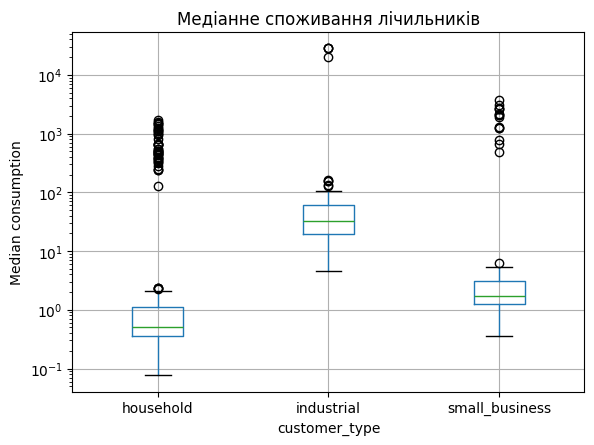

In [ ]:
# TODO: D-D

# медіана кожного лічильника
meter_median = (
    df.groupby("meter_id")["consumption_kwh"]
      .median()
)

# customer_type кожного лічильника
meter_type = (
    df.groupby("meter_id")["customer_type"]
      .first()
)

# медіана всіх рядків кожного customer_type
type_median = (
    df.groupby("customer_type")["consumption_kwh"]
      .median()
)

ratio = meter_median / meter_type.map(type_median)

wh_meters = ratio[ratio > 100].index.tolist()

print("D-D. Лічильників у Вт·год:", len(wh_meters))

normal_ratio = ratio[ratio <= 100]
wrong_ratio = ratio[ratio > 100]

if len(normal_ratio):
    print(
        "Найбільше відношення серед нормальних:",
        normal_ratio.max()
    )

if len(wrong_ratio):
    print(
        "Найменше відношення серед Вт·год:",
        wrong_ratio.min()
    )

# графік до виправлення медіан лічильників
plot_data = pd.DataFrame({
    "median_kwh": meter_median,
    "customer_type": meter_type
})

plot_data.boxplot(
    column="median_kwh",
    by="customer_type"
)

plt.yscale("log")
plt.ylabel("Median consumption")
plt.title("Медіанне споживання лічильників")
plt.suptitle("")
plt.show()

# виправлення    
df.loc[
    df["meter_id"].isin(wh_meters),
    "consumption_kwh"
] /= 1000

# перевірка
min_kwh = {
    "household": 0.01,
    "small_business": 0.02,
    "industrial": 1
}

max_kwh = {
    "household": 10,
    "small_business": 60,
    "industrial": 1200
}

valid_consumption = df["consumption_kwh"].between(
    df["customer_type"].map(min_kwh),
    df["customer_type"].map(max_kwh)
)

print(
    "Рядків поза допустимими межами:",
    (~valid_consumption).sum()
)

## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [8]:
# TODO: D-A
end_time = pd.Timestamp("2026-02-01 23:00")

last_ts = df.groupby("meter_id")["ts"].max()

silence_hours = (
    (end_time - last_ts)
    / pd.Timedelta(hours=1)
)

silent = silence_hours[
    silence_hours > 48
].index.tolist()

print("D-A. Замовклих лічильників:", len(silent))

not_silent_values = silence_hours[
    silence_hours <= 48
]

silent_values = silence_hours[
    silence_hours > 48
]

if len(not_silent_values):
    print(
        "Найбільша тиша серед нормальних:",
        not_silent_values.max()
    )

if len(silent_values):
    print(
        "Найменша тиша серед замовклих:",
        silent_values.min()
    )

D-A. Замовклих лічильників: 48
Найбільша тиша серед нормальних: 1.0
Найменша тиша серед замовклих: 142.0


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

D-B. Завмерлих лічильників: 40
Найменша частка серед нормальних: 0.8403614457831325
Найбільша частка серед завмерлих: 0.49473684210526314


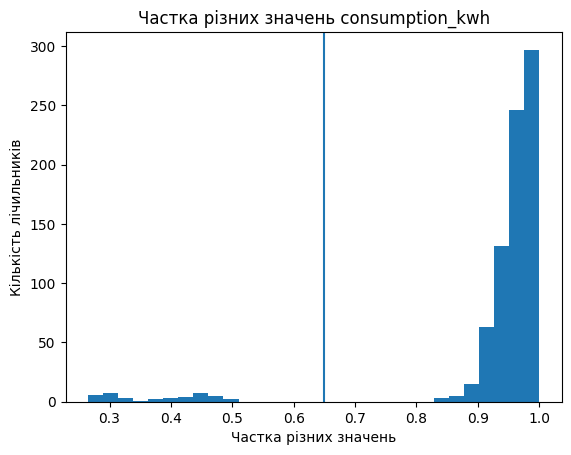

In [9]:
# TODO: D-B
unique_values = (
    df.groupby("meter_id")["consumption_kwh"]
      .nunique()
)

records_count = (
    df.groupby("meter_id")["consumption_kwh"]
      .size()
)

unique_share = unique_values / records_count

frozen = unique_share[
    unique_share < 0.65
].index.tolist()

print("D-B. Завмерлих лічильників:", len(frozen))

normal_frozen = unique_share[
    unique_share >= 0.65
]

bad_frozen = unique_share[
    unique_share < 0.65
]

if len(normal_frozen):
    print(
        "Найменша частка серед нормальних:",
        normal_frozen.min()
    )

if len(bad_frozen):
    print(
        "Найбільша частка серед завмерлих:",
        bad_frozen.max()
    )

# гістограма 
plt.hist(unique_share, bins=30)

plt.xlabel("Частка різних значень")
plt.ylabel("Кількість лічильників")
plt.title("Частка різних значень consumption_kwh")

plt.axvline(0.65)

plt.show()

## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [10]:
# TODO: знайдіть і приберіть колонку-копію та record_ts
numeric_df = df.select_dtypes("number")
corr = numeric_df.corr().abs()
print(corr)

result = df.drop(
    columns=[
        "years_connected",
        "record_ts"
    ]
)

corr = result.select_dtypes("number").corr().abs()

copies = [
    (a, b)
    for a in corr
    for b in corr
    if a < b and corr.loc[a, b] > 0.95
]

print("Колонки-копії:", copies)

                  consumption_kwh  electric_heating  connection_year  \
consumption_kwh          1.000000          0.097382         0.009771   
electric_heating         0.097382          1.000000         0.043630   
connection_year          0.009771          0.043630         1.000000   
years_connected          0.011954          0.044338         0.999129   

                  years_connected  
consumption_kwh          0.011954  
electric_heating         0.044338  
connection_year          0.999129  
years_connected          1.000000  
Колонки-копії: []


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [11]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (516214, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [12]:
# TODO: homes — рядки result для домогосподарств без лічильників із silent і frozen
# кожну умову беріть у дужки: result[(умова 1) & ~(умова 2)]
homes = result[
    (result["customer_type"] == "household")
    & (~result["meter_id"].isin(silent))
    & (~result["meter_id"].isin(frozen))
]

per_meter = homes.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)

per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (
    per_meter["tariff"] == "dual_zone"
).astype(int)

x = per_meter[
    ["electric_heating", "dual_zone"]
]

y = per_meter["kwh_per_day"]

model = LinearRegression().fit(x, y)
print("лічильників:", len(per_meter))
print(f"a = {model.intercept_:.2f}, b₁ (опалення) = {model.coef_[0]:.2f}, b₂ (двозонний тариф) = {model.coef_[1]:.2f}, R² = {model.score(x, y):.3f}")

лічильників: 481
a = 10.39, b₁ (опалення) = 19.09, b₂ (двозонний тариф) = 2.61, R² = 0.725
